# Notebook Purpose

This notebook is designed to perform an initial quality and consistency audit of the dataset before modeling.

- **Inspect dataset structure**
    - Review available files, columns, labels, and metadata.
    - Understand how images and patient-level information are organized.

- **Check for duplicate images**
    - Identify repeated image entries (exact duplicates and potential repeated paths/IDs).
    - Quantify duplicates and flag records for potential removal.

- **Analyze label consistency at patient level**
    - Find patients associated with both **positive** and **negative** labels.
    - Highlight potential annotation conflicts, temporal effects, or data leakage risks.

In [2]:
import torch
import matplotlib.pyplot as plt
%matplotlib widget

input_path = r"C:\Users\nicco\Documents\PoliTo\Anno 2\Centrale\Tesi\LPAC_project\data\imgNum_770_imgSize_448_04-07_MC.pt"
dataset = torch.load(input_path, map_location="cpu")

=== DATASET OVERVIEW ===
type(dataset): dict
keys: ['images', 'labels', 'patients', 'paths', 'image_size']
Image_size: 3x448x448

images number:  770
labels number:  770
patientIDs number:  770
Unique patientIDs:  133
number of paths:  770

=== SAMPLE DATA ===
Sample image tensor shape:  torch.Size([3, 448, 448])
Sample label:  tensor(0)
Sample patient ID:  tensor(2754428630712)

=== Image example ===
Label: 0, Patient ID: 2754428630712


(np.float64(-0.5), np.float64(447.5), np.float64(447.5), np.float64(-0.5))

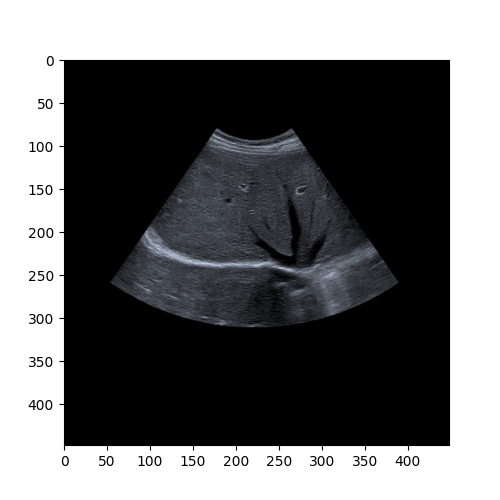

In [3]:
print("=== DATASET OVERVIEW ===")
print(f"type(dataset): {type(dataset).__name__}")
print(f"keys: {list(dataset.keys())}")
number_of_channels = dataset["images"].shape[1]
print(f"Image_size: {number_of_channels}x{dataset['image_size']}x{dataset['image_size']}")

print("\nimages number: ", len(dataset["images"]))
print("labels number: ", len(dataset["labels"]))
print("patientIDs number: ", len(dataset["patients"]))
print("Unique patientIDs: ", len(dataset["patients"].unique()))
print("number of paths: ", len(dataset["paths"]))

random_id = torch.randint(0, len(dataset["images"]), (1,)).item()
print("\n=== SAMPLE DATA ===")
print("Sample image tensor shape: ", dataset["images"][random_id].shape)
print("Sample label: ", dataset["labels"][random_id])
print("Sample patient ID: ", dataset["patients"][random_id])

print("\n=== Image example ===")
print(f"Label: {dataset['labels'][random_id]}, Patient ID: {dataset['patients'][random_id]}")
img = dataset["images"][random_id].permute(1, 2, 0) 
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("on")



In [4]:
# check if there patients labeled both as positive and negative
patient_ids = dataset["patients"].unique()
pathology_map = dict()

for patient in patient_ids:
    pathology_map[patient.item()] = set()
for patient, label in zip(dataset["patients"], dataset["labels"]):
    pathology_map[patient.item()].add(label.item())
    
mixed_patients = {patient: labels for patient, labels in pathology_map.items() if len(labels) > 1}
print("\n=== Patients with mixed labels ===")
if not mixed_patients:
    print("No patients with mixed labels found.")
for patient, labels in mixed_patients.items():
    print(f"Patient ID: {patient}, Labels: {labels}")



=== Patients with mixed labels ===
No patients with mixed labels found.


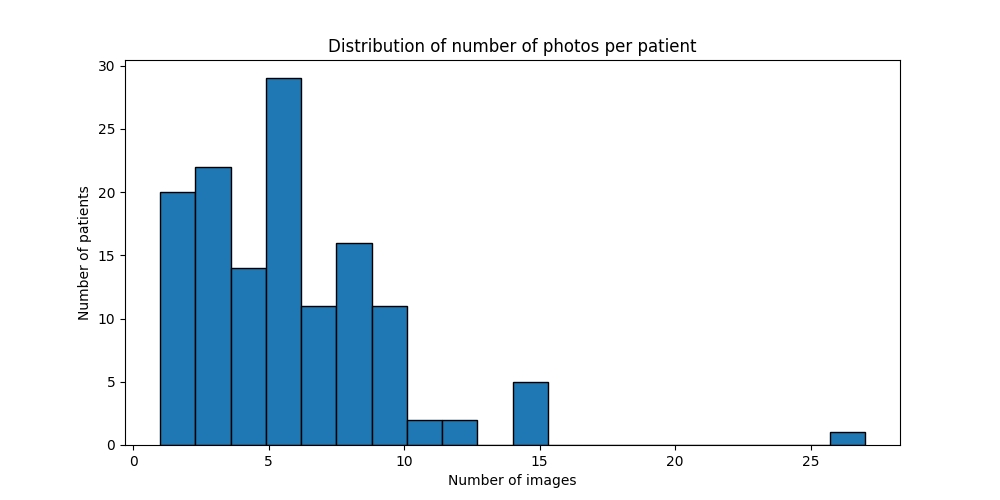

In [5]:
# check distribution of number of photos per patient

import matplotlib.pyplot as plt
from collections import Counter

patient_ids = [p.item() if hasattr(p, "item") else p for p in dataset["patients"]]
samples_counts = list(Counter(patient_ids).values())

plt.figure(figsize=(10, 5))
plt.hist(samples_counts, bins=20, edgecolor="black")
plt.title("Distribution of number of photos per patient")
plt.xlabel("Number of images")
plt.ylabel("Number of patients")
plt.show()


In [6]:
from pathlib import Path
import hashlib

def get_patient_id(patient):
    return patient.item() if hasattr(patient, "item") else patient

def make_img_hash(img):
    x = img.detach().cpu().contiguous()
    payload = (
        str(tuple(x.shape)).encode("utf-8")
        + b"|"
        + str(x.dtype).encode("utf-8")
        + b"|"
        + x.numpy().tobytes()
    )
    return hashlib.sha256(payload).hexdigest()

# 1) Group all images by hash
hash_map = {}

for patient, img, path in zip(dataset["patients"], dataset["images"], dataset["paths"]):
    patient_id = get_patient_id(patient)
    img_hash = make_img_hash(img)

    if img_hash not in hash_map:
        hash_map[img_hash] = []

    hash_map[img_hash].append({
        "patient": patient_id,
        "path": path
    })

# 2) Analyze duplicate groups
same_patient_duplicates = {}       # patient_id -> list of duplicate path groups
different_patient_duplicates = []  # list of groups involving multiple patients

total_duplicate_groups = 0
total_images_in_duplicate_groups = 0
total_duplicate_images = 0  # counts extras beyond the first image in each group

for img_hash, items in hash_map.items():
    if len(items) < 2:
        continue  # not a duplicate group

    total_duplicate_groups += 1
    total_images_in_duplicate_groups += len(items)
    total_duplicate_images += len(items) - 1

    # Split this hash group by patient
    by_patient = {}
    for info in items:
        patient_id = info["patient"]
        if patient_id not in by_patient:
            by_patient[patient_id] = []
        by_patient[patient_id].append(info["path"])

    # Duplicates inside the same patient
    for patient_id, paths in by_patient.items():
        if len(paths) > 1:
            if patient_id not in same_patient_duplicates:
                same_patient_duplicates[patient_id] = []
            same_patient_duplicates[patient_id].append(paths)

    # Duplicates across different patients
    if len(by_patient) > 1:
        different_patient_duplicates.append(by_patient)

# 3) Print summary
print("Duplicate hash groups:", total_duplicate_groups)
print("Images involved in duplicate groups:", total_images_in_duplicate_groups)
print("Total duplicate images (excluding one original per group):", total_duplicate_images)

print("Same-patient duplicate groups:", sum(len(v) for v in same_patient_duplicates.values()))
print("Different-patient duplicate groups:", len(different_patient_duplicates))

print("\nPrinting same-patient duplicates:")
for patient_id, groups in list(same_patient_duplicates.items())[:]:
    print(f"  Patient {patient_id}:")
    for i, paths in enumerate(groups, start=1):
        file_names = [Path(path).name for path in paths]
        print(f"    Group {i}: {file_names}")

print("\nPrinting different-patient duplicates:")
for i, group in enumerate(different_patient_duplicates[:], start=1):
    print(f"  Group {i}:")
    for patient_id, paths in group.items():
        file_names = [Path(path).name for path in paths]
        print(f"    Patient {patient_id}: {file_names}")
        
    

Duplicate hash groups: 0
Images involved in duplicate groups: 0
Total duplicate images (excluding one original per group): 0
Same-patient duplicate groups: 0
Different-patient duplicate groups: 0

Printing same-patient duplicates:

Printing different-patient duplicates:
